# Очистка и преобразование данных в Python

## Единый учебный notebook для очного практического занятия

Этот notebook собран так, чтобы всё было в одном месте:

1. Генерация учебных данных.
2. Проверка окружения.
3. Короткое повторение Python.
4. Загрузка данных.
5. Диагностика качества.
6. Очистка данных.
7. Преобразование данных.
8. Объединение таблиц.
9. Группировки и сводные таблицы.
10. Сохранение результата.
11. Самостоятельная мини-практика.
12. Подсказки по типовым ошибкам.

## Как работать с notebook

Запускайте ячейки строго сверху вниз.

Если появилась ошибка:

1. Не переходите дальше.
2. Прочитайте последнюю строку ошибки.
3. Вернитесь к предыдущей ячейке.
4. Проверьте, создана ли нужная переменная.
5. Проверьте, правильно ли написано имя файла или столбца.

# Рабочая ситуация

Вы работаете аналитиком в компании, которая продаёт товары через разные каналы:

- online;
- marketplace;
- offline;
- partner.

Руководителю нужен подготовленный файл с продажами для отчёта.

В исходных данных специально заложены учебные ошибки:

- пропуски;
- дубликаты;
- некорректные даты;
- лишние пробелы;
- разные варианты написания одного значения;
- отрицательные количества;
- нулевые или отрицательные цены;
- некорректные скидки;
- несовпадения между основной таблицей и справочниками.

Ваша задача — подготовить данные так, чтобы по ним можно было считать выручку, строить группировки и делать выводы.

# Что получится в результате

В notebook будет выполнен полный учебный цикл подготовки данных:

- создание контролируемо загрязнённых данных;
- первичная диагностика качества;
- обработка пропусков удалением, константой и средним значением;
- очистка текста и дат;
- поиск и удаление дубликатов;
- проверка бизнес-правил;
- сохранение исключённых строк в карантин;
- расчёт выручки;
- обнаружение выбросов методом межквартильного размаха;
- обнаружение выбросов методом z-score;
- формальная валидация через `assert`;
- объединение таблиц с проверкой отношения ключей;
- подготовка аналитических таблиц и графика;
- сохранение очищенных данных, карантина и отчёта качества.

Статистический выброс в этой работе не удаляется автоматически. Он помечается для дополнительной проверки.

# Часть 1. Проверка окружения

Сначала проверим, что Python работает и мы понимаем, в какой папке выполняется notebook.

Это важно: если Python ищет файл не в той папке, появится ошибка `FileNotFoundError`.

In [1]:
from pathlib import Path
import sys

print("Версия Python:")
print(sys.version)

print("\nТекущая рабочая папка:")
print(Path.cwd())

Версия Python:
3.13.5 (main, May  5 2026, 21:05:52) [GCC 14.2.0]

Текущая рабочая папка:
/mnt/data


## Подсказка

`Path.cwd()` показывает текущую рабочую папку.

Если дальше Python не сможет найти файл, первое, что нужно проверить, — именно текущую папку.

# Часть 2. Импорт библиотек

Нам понадобятся:

- `pandas` — работа с таблицами;
- `numpy` — работа с числами и пропусками;
- `matplotlib` — базовая визуализация;
- `json` — запись JSON-файла;
- `random` — генерация учебных данных.

In [2]:
try:
    import json
    import random
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    print("Библиотеки импортированы успешно")
    print("pandas:", pd.__version__)
    print("numpy:", np.__version__)
except ImportError as error:
    print("Ошибка импорта библиотеки:")
    print(error)

Библиотеки импортированы успешно
pandas: 2.2.3
numpy: 2.3.5


## Что делать, если появилась ошибка `ModuleNotFoundError`

Такой текст означает, что библиотека не установлена.

Варианты решения:

1. В Google Colab большинство нужных библиотек уже есть.
2. Если работаете локально, можно установить зависимости командой:

```python
%pip install pandas numpy matplotlib openpyxl
```

3. После установки перезапустите ячейку импорта.

# Часть 3. Создание учебных данных внутри notebook

Чтобы не зависеть от внешних файлов, этот notebook сам создаёт учебные данные.

Будут созданы папки:

```text
data/raw/
outputs/
```

И файлы:

```text
data/raw/sales.csv
data/raw/products.xlsx
data/raw/clients.csv
data/raw/regions.json
```

В данные специально добавлены ошибки, чтобы их можно было найти и исправить.

In [3]:
from pathlib import Path
import json
import random
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

RAW_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Папка исходных данных:", RAW_DIR)
print("Папка результатов:", OUTPUT_DIR)

Папка исходных данных: /mnt/data/data/raw
Папка результатов: /mnt/data/outputs


## Создаём справочник товаров

Справочник товаров содержит:

- `product_id` — код товара;
- `product_name` — название товара;
- `category` — категория;
- `cost` — себестоимость.

В справочнике специально есть лишние пробелы и разный регистр в категориях.

In [4]:
products = pd.DataFrame(
    [
        ["P001", "Laptop Basic 14", " Electronics", 42000],
        ["P002", "Laptop Pro 15", "electronics ", 68000],
        ["P003", "Wireless Mouse", "Accessories", 700],
        [" P004", "Mechanical Keyboard", " accessories", 2800],
        ["P005", "Office Chair", "Furniture", 6500],
        ["P006", "Standing Desk", "furniture ", 14500],
        ["P007", "USB-C Hub", "Accessories", 1800],
        ["P008", "Monitor 24", "Electronics", 11800],
        ["P009", "Monitor 27", " electronics", 16500],
        ["P010", "Webcam HD", "Accessories ", 2300],
        ["P011", "Notebook Stand", "accessories", 1200],
        ["P012", "Desk Lamp", "Furniture", 1900],
    ],
    columns=["product_id", "product_name", "category", "cost"],
)

display(products)

,product_id,product_name,category,cost
0,P001,Laptop Basic 14,Electronics,42000
1,P002,Laptop Pro 15,electronics,68000
2,P003,Wireless Mouse,Accessories,700
3,P004,Mechanical Keyboard,accessories,2800
4,P005,Office Chair,Furniture,6500
5,P006,Standing Desk,furniture,14500
6,P007,USB-C Hub,Accessories,1800
7,P008,Monitor 24,Electronics,11800
8,P009,Monitor 27,electronics,16500
9,P010,Webcam HD,Accessories,2300


## Создаём справочник клиентов

Справочник клиентов содержит:

- `client_id` — код клиента;
- `segment` — сегмент клиента;
- `registration_date` — дата регистрации;
- `loyalty_level` — уровень лояльности.

В одном ключе клиента специально есть лишний пробел.

In [5]:
segments = ["B2C", "B2B", "SMB", "Enterprise"]
loyalty_levels = ["Bronze", "Silver", "Gold", "Platinum"]

clients_data = []
for i in range(1, 31):
    clients_data.append(
        {
            "client_id": f"C{i:03d}",
            "segment": random.choice(segments),
            "registration_date": (
                pd.Timestamp("2025-01-01")
                + pd.Timedelta(days=random.randint(0, 420))
            ).strftime("%Y-%m-%d"),
            "loyalty_level": random.choice(loyalty_levels),
        }
    )

clients = pd.DataFrame(clients_data)

# Специальная учебная ошибка: лишний пробел в ключе клиента
clients.loc[5, "client_id"] = " C006"

display(clients.head(10))

,client_id,segment,registration_date,loyalty_level
0,C001,B2C,2025-01-13,Gold
1,C002,B2B,2025-04-25,Silver
2,C003,B2C,2025-12-13,Bronze
3,C004,Enterprise,2025-01-17,Bronze
4,C005,B2C,2025-04-22,Silver
5,C006,B2C,2025-10-15,Silver
6,C007,Enterprise,2025-04-23,Platinum
7,C008,SMB,2026-02-19,Bronze
8,C009,B2B,2025-12-24,Platinum
9,C010,SMB,2025-05-23,Silver


## Создаём справочник регионов

Справочник регионов содержит:

- `region_id` — код региона;
- `region_name` — название региона;
- `macro_region` — макрорегион.

In [6]:
regions = pd.DataFrame(
    [
        {"region_id": "R01", "region_name": "Москва", "macro_region": "Центральный"},
        {"region_id": "R02", "region_name": "Санкт-Петербург", "macro_region": "Северо-Запад"},
        {"region_id": "R03", "region_name": "Казань", "macro_region": "Приволжский"},
        {"region_id": "R04", "region_name": "Екатеринбург", "macro_region": "Уральский"},
        {"region_id": "R05", "region_name": "Новосибирск", "macro_region": "Сибирский"},
        {"region_id": "R06", "region_name": "Ростов-на-Дону", "macro_region": "Южный"},
        {"region_id": "R07", "region_name": "Владивосток", "macro_region": "Дальневосточный"},
    ]
)

display(regions)

,region_id,region_name,macro_region
0,R01,Москва,Центральный
1,R02,Санкт-Петербург,Северо-Запад
2,R03,Казань,Приволжский
3,R04,Екатеринбург,Уральский
4,R05,Новосибирск,Сибирский
5,R06,Ростов-на-Дону,Южный
6,R07,Владивосток,Дальневосточный


## Создаём таблицу продаж

Основная таблица продаж содержит:

- `order_id` — номер заказа;
- `order_date` — дата заказа;
- `client_id` — код клиента;
- `product_id` — код товара;
- `region_id` — код региона;
- `channel` — канал продаж;
- `quantity` — количество;
- `unit_price` — цена за единицу;
- `discount` — скидка.

В эту таблицу специально добавлены ошибки качества.

In [7]:
clean_product_ids = [value.strip() for value in products["product_id"].tolist()]
clean_client_ids = [value.strip() for value in clients["client_id"].tolist()]
region_ids = regions["region_id"].tolist()

# Связываем товар с его себестоимостью.
# Цена продажи будет зависеть от конкретного товара, а не генерироваться случайно
# в одном широком диапазоне для всех товаров.
cost_by_product = {
    product_id.strip(): cost
    for product_id, cost in zip(products["product_id"], products["cost"])
}

channels = [
    "online",
    "Online",
    "ONLINE ",
    " marketplace",
    "marketplace",
    "offline",
    "Offline ",
    "partner",
    "PARTNER ",
]

orders = []

for i in range(1, 121):
    product_id = random.choice(clean_product_ids)
    client_id = random.choice(clean_client_ids)
    region_id = random.choice(region_ids)
    order_date = pd.Timestamp("2026-04-01") + pd.Timedelta(days=random.randint(0, 75))

    quantity = random.randint(1, 7)

    # Цена продажи зависит от себестоимости выбранного товара.
    # Наценка находится в разумном учебном диапазоне.
    base_cost = cost_by_product[product_id]
    unit_price = round(base_cost * random.uniform(1.15, 1.45), 2)

    discount = random.choice([0, 0.05, 0.10, 0.15, 0.20])
    delivery_days = random.randint(1, 10)

    orders.append(
        {
            "order_id": f"ORD-{1000 + i}",
            "order_date": order_date.strftime("%Y-%m-%d"),
            "client_id": client_id,
            "product_id": product_id,
            "region_id": region_id,
            "channel": random.choice(channels),
            "quantity": quantity,
            "unit_price": unit_price,
            "discount": discount,
            "delivery_days": delivery_days,
        }
    )

sales = pd.DataFrame(orders)

# Добавляем контролируемые учебные ошибки

# 1. Дубликат заказа
duplicate_row = sales.loc[9].copy()
sales = pd.concat([sales, pd.DataFrame([duplicate_row])], ignore_index=True)

# 2. Пропуски региона
sales.loc[3, "region_id"] = np.nan
sales.loc[24, "region_id"] = np.nan

# 3. Пропуски скидки
sales.loc[7, "discount"] = np.nan
sales.loc[39, "discount"] = np.nan

# 4. Пропуски числового признака delivery_days
sales.loc[11, "delivery_days"] = np.nan
sales.loc[37, "delivery_days"] = np.nan
sales.loc[84, "delivery_days"] = np.nan

# 5. Некорректные даты
sales.loc[14, "order_date"] = "not_a_date"
sales.loc[52, "order_date"] = "2026/99/99"

# 6. Некорректные количества
sales.loc[18, "quantity"] = -2
sales.loc[43, "quantity"] = 0

# 7. Некорректные цены
sales.loc[21, "unit_price"] = 0
sales.loc[61, "unit_price"] = -1500

# 8. Некорректные скидки
sales.loc[28, "discount"] = 1.5
sales.loc[66, "discount"] = -0.1

# 9. Несуществующий товар
sales.loc[34, "product_id"] = "P999"

# 10. Несуществующий регион
sales.loc[46, "region_id"] = "R99"

# 11. Лишние пробелы в ключах
sales.loc[58, "product_id"] = " P003 "
sales.loc[75, "client_id"] = " C010 "

# 12. Редкие, но положительные значения для демонстрации выбросов.
# Они не удаляются как ошибки бизнес-правил.
sales.loc[80, "quantity"] = 25
sales.loc[95, "unit_price"] = round(sales.loc[95, "unit_price"] * 8, 2)

display(sales.head(15))
print("Размер sales:", sales.shape)

,order_id,order_date,client_id,product_id,region_id,channel,quantity,unit_price,discount,delivery_days
0,ORD-1001,2026-05-21,C021,P004,R04,marketplace,6,3605.44,0.10,3.0
1,ORD-1002,2026-05-04,C018,P012,R05,offline,6,2518.21,0.20,7.0
2,ORD-1003,2026-06-03,C005,P004,R05,ONLINE,1,3854.86,0.00,3.0
3,ORD-1004,2026-04-09,C014,P011,NaN,marketplace,4,1517.38,0.15,9.0
4,ORD-1005,2026-04-15,C028,P009,R01,Online,6,23354.70,0.10,6.0
5,ORD-1006,2026-05-29,C014,P005,R02,ONLINE,1,9334.94,0.10,9.0
6,ORD-1007,2026-05-09,C030,P009,R01,ONLINE,7,22137.80,0.20,4.0
7,ORD-1008,2026-06-09,C025,P006,R02,offline,7,20687.59,NaN,10.0
8,ORD-1009,2026-05-17,C001,P008,R01,marketplace,7,16425.98,0.05,1.0
9,ORD-1010,2026-06-02,C003,P010,R01,ONLINE,7,2692.76,0.20,3.0


Размер sales: (121, 10)


## Сохраняем учебные данные в файлы

Теперь сохраним созданные таблицы в разные форматы:

- продажи — CSV;
- товары — Excel;
- клиенты — CSV;
- регионы — JSON.

Так мы отработаем загрузку данных из разных источников.

In [8]:
sales.to_csv(RAW_DIR / "sales.csv", index=False, encoding="utf-8")
products.to_excel(RAW_DIR / "products.xlsx", index=False)
clients.to_csv(RAW_DIR / "clients.csv", index=False, encoding="utf-8")

with open(RAW_DIR / "regions.json", "w", encoding="utf-8") as file:
    json.dump(
        regions.to_dict(orient="records"),
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Файлы созданы:")
print(RAW_DIR / "sales.csv")
print(RAW_DIR / "products.xlsx")
print(RAW_DIR / "clients.csv")
print(RAW_DIR / "regions.json")

Файлы созданы:
/mnt/data/data/raw/sales.csv
/mnt/data/data/raw/products.xlsx
/mnt/data/data/raw/clients.csv
/mnt/data/data/raw/regions.json


# Часть 4. Проверяем наличие файлов

Даже если файлы созданы только что, полезно выполнить проверку.

Это формирует рабочую привычку аналитика: сначала проверить входные данные, потом анализировать.

In [9]:
required_files = [
    Path("data/raw/sales.csv"),
    Path("data/raw/products.xlsx"),
    Path("data/raw/clients.csv"),
    Path("data/raw/regions.json"),
]

print("Проверяем файлы:")

for file_path in required_files:
    if file_path.exists():
        print("OK:", file_path)
    else:
        print("НЕ НАЙДЕН:", file_path)

Проверяем файлы:
OK: data/raw/sales.csv
OK: data/raw/products.xlsx
OK: data/raw/clients.csv
OK: data/raw/regions.json


# Часть 5. Мини-повторение Python

Перед pandas коротко вспомним базовые элементы Python.

Эта часть нужна, чтобы код дальше был понятнее.

## Переменные

Переменная — это имя, под которым хранится значение.

Пример: мы можем сохранить количество, цену и скидку, а затем посчитать выручку.

In [10]:
quantity = 3
unit_price = 1250
discount = 0.10

revenue = quantity * unit_price * (1 - discount)

print("Количество:", quantity)
print("Цена:", unit_price)
print("Скидка:", discount)
print("Выручка:", revenue)

Количество: 3
Цена: 1250
Скидка: 0.1
Выручка: 3375.0


## Список

Список хранит несколько значений.

Например, список каналов продаж.

In [11]:
channels_list = ["online", "marketplace", "offline", "partner"]

print(channels_list)
print("Первый элемент:", channels_list[0])
print("Количество элементов:", len(channels_list))

['online', 'marketplace', 'offline', 'partner']
Первый элемент: online
Количество элементов: 4


## Словарь

Словарь хранит значения по ключам.

Это похоже на одну строку таблицы: есть название поля и значение.

In [12]:
one_order = {
    "order_id": "ORD-1001",
    "channel": "online",
    "quantity": 3,
    "unit_price": 1250,
}

print(one_order)
print("Канал продаж:", one_order["channel"])

{'order_id': 'ORD-1001', 'channel': 'online', 'quantity': 3, 'unit_price': 1250}
Канал продаж: online


## Условие

Условие помогает проверить правило.

Например: количество должно быть больше нуля.

In [13]:
quantity = -2

if quantity <= 0:
    print("Ошибка: количество должно быть больше нуля")
else:
    print("Количество корректное")

Ошибка: количество должно быть больше нуля


## Цикл

Цикл повторяет одно действие несколько раз.

Например, можно проверить список файлов.

In [14]:
file_names = ["sales.csv", "products.xlsx", "clients.csv", "regions.json"]

for file_name in file_names:
    print("Нужно проверить файл:", file_name)

Нужно проверить файл: sales.csv
Нужно проверить файл: products.xlsx
Нужно проверить файл: clients.csv
Нужно проверить файл: regions.json


## Функция

Функция нужна, чтобы повторять действие по понятному имени.

In [15]:
def calculate_revenue(quantity, unit_price, discount):
    result = quantity * unit_price * (1 - discount)
    return result

print(calculate_revenue(2, 1000, 0.10))
print(calculate_revenue(5, 500, 0))

1800.0
2500


# Часть 6. Загружаем данные из файлов

Теперь загрузим файлы, которые были созданы выше.

Важно: дальше работаем не с таблицами, которые лежат в памяти после генерации, а именно с файлами. Это ближе к реальной работе аналитика.

In [16]:
sales = pd.read_csv("data/raw/sales.csv")
products = pd.read_excel("data/raw/products.xlsx")
clients = pd.read_csv("data/raw/clients.csv")
regions = pd.read_json("data/raw/regions.json")

print("Данные загружены")
print("sales:", sales.shape)
print("products:", products.shape)
print("clients:", clients.shape)
print("regions:", regions.shape)

Данные загружены
sales: (121, 10)
products: (12, 4)
clients: (30, 4)
regions: (7, 3)


## Смотрим первые строки

`head()` показывает первые строки таблицы.

Это нужно, чтобы быстро понять структуру данных.

In [17]:
display(sales.head())

,order_id,order_date,client_id,product_id,region_id,channel,quantity,unit_price,discount,delivery_days
0,ORD-1001,2026-05-21,C021,P004,R04,marketplace,6,3605.44,0.10,3.0
1,ORD-1002,2026-05-04,C018,P012,R05,offline,6,2518.21,0.20,7.0
2,ORD-1003,2026-06-03,C005,P004,R05,ONLINE,1,3854.86,0.00,3.0
3,ORD-1004,2026-04-09,C014,P011,NaN,marketplace,4,1517.38,0.15,9.0
4,ORD-1005,2026-04-15,C028,P009,R01,Online,6,23354.70,0.10,6.0


In [18]:
display(products.head())

,product_id,product_name,category,cost
0,P001,Laptop Basic 14,Electronics,42000
1,P002,Laptop Pro 15,electronics,68000
2,P003,Wireless Mouse,Accessories,700
3,P004,Mechanical Keyboard,accessories,2800
4,P005,Office Chair,Furniture,6500


In [19]:
display(clients.head())

,client_id,segment,registration_date,loyalty_level
0,C001,B2C,2025-01-13,Gold
1,C002,B2B,2025-04-25,Silver
2,C003,B2C,2025-12-13,Bronze
3,C004,Enterprise,2025-01-17,Bronze
4,C005,B2C,2025-04-22,Silver


In [20]:
display(regions.head())

,region_id,region_name,macro_region
0,R01,Москва,Центральный
1,R02,Санкт-Петербург,Северо-Запад
2,R03,Казань,Приволжский
3,R04,Екатеринбург,Уральский
4,R05,Новосибирск,Сибирский


# Часть 7. Первичная диагностика таблицы продаж

Перед очисткой нужно понять, что именно не так с данными.

Проверяем:

1. Размер таблицы.
2. Названия столбцов.
3. Типы данных.
4. Пропуски.
5. Дубликаты.
6. Некорректные значения.

In [21]:
print("Размер sales:")
print(sales.shape)

print("\nСтолбцы sales:")
print(sales.columns.tolist())

Размер sales:
(121, 10)

Столбцы sales:
['order_id', 'order_date', 'client_id', 'product_id', 'region_id', 'channel', 'quantity', 'unit_price', 'discount', 'delivery_days']


## Проверяем типы данных

Типы данных показывают, как pandas понял каждый столбец.

Если дата прочиталась как `object`, значит пока это текст, а не дата.

In [22]:
display(sales.dtypes)
sales.info()

order_id          object
order_date        object
client_id         object
product_id        object
region_id         object
channel           object
quantity           int64
unit_price       float64
discount         float64
delivery_days    float64
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       121 non-null    object 
 1   order_date     121 non-null    object 
 2   client_id      121 non-null    object 
 3   product_id     121 non-null    object 
 4   region_id      119 non-null    object 
 5   channel        121 non-null    object 
 6   quantity       121 non-null    int64  
 7   unit_price     121 non-null    float64
 8   discount       119 non-null    float64
 9   delivery_days  118 non-null    float64
dtypes: float64(3), int64(1), object(6)
memory usage: 9.6+ KB


## Проверяем пропуски

`isna().sum()` показывает количество пропусков по каждому столбцу.

In [23]:
display(sales.isna().sum())

order_id         0
order_date       0
client_id        0
product_id       0
region_id        2
channel          0
quantity         0
unit_price       0
discount         2
delivery_days    3
dtype: int64

## Проверяем дубликаты

Заказ должен быть уникальным по `order_id`.

Если один и тот же `order_id` встречается повторно, показатели могут быть завышены.

In [24]:
duplicates_count = sales["order_id"].duplicated().sum()
print("Количество дубликатов order_id:", duplicates_count)

duplicate_rows = sales[sales["order_id"].duplicated(keep=False)]
display(duplicate_rows)

Количество дубликатов order_id: 1


,order_id,order_date,client_id,product_id,region_id,channel,quantity,unit_price,discount,delivery_days
9,ORD-1010,2026-06-02,C003,P010,R01,ONLINE,7,2692.76,0.2,3.0
120,ORD-1010,2026-06-02,C003,P010,R01,ONLINE,7,2692.76,0.2,3.0


## Проверяем текстовые значения

Для человека `online`, `Online` и `ONLINE ` выглядят похоже.

Для Python это разные значения.

Поэтому перед анализом нужно нормализовать текст.

In [25]:
print("Уникальные значения channel:")
display(sales["channel"].unique())

Уникальные значения channel:


array([' marketplace', 'offline', 'ONLINE ', 'marketplace', 'Online',
       'PARTNER ', 'online', 'partner', 'Offline '], dtype=object)

## Проверяем числовые бизнес-правила

Правила:

| Поле | Корректное значение |
|---|---|
| `quantity` | больше 0 |
| `unit_price` | больше 0 |
| `discount` | от 0 до 1 |

In [26]:
print("Минимальное quantity:", sales["quantity"].min())
print("Минимальное unit_price:", sales["unit_price"].min())
print("Минимальное discount:", sales["discount"].min())
print("Максимальное discount:", sales["discount"].max())

Минимальное quantity: -2
Минимальное unit_price: -1500.0
Минимальное discount: -0.1
Максимальное discount: 1.5


## Описательная статистика числовых столбцов

Перед очисткой полезно посмотреть распределение числовых значений.

`describe()` показывает количество значений, среднее, стандартное отклонение,
квартили, минимум и максимум. На этом этапе мы только диагностируем данные.

In [27]:
numeric_columns = [
    "quantity",
    "unit_price",
    "discount",
    "delivery_days",
]

display(sales[numeric_columns].describe())

,quantity,unit_price,discount,delivery_days
count,121.000000,121.000000,119.000000,118.000000
mean,4.272727,22313.926364,0.122269,5.457627
std,2.822528,66066.525146,0.146383,2.913699
min,-2.000000,-1500.000000,-0.100000,1.000000
25%,2.000000,2440.680000,0.050000,3.000000
50%,4.000000,7631.610000,0.100000,5.000000
75%,6.000000,19028.420000,0.150000,8.000000
max,25.000000,691289.360000,1.500000,10.000000


In [28]:
print("Строки с quantity <= 0")
display(sales[sales["quantity"] <= 0])

print("Строки с unit_price <= 0")
display(sales[sales["unit_price"] <= 0])

print("Строки со скидкой вне диапазона 0-1")
display(
    sales[
        (sales["discount"] < 0) |
        (sales["discount"] > 1)
    ]
)

Строки с quantity <= 0


,order_id,order_date,client_id,product_id,region_id,channel,quantity,unit_price,discount,delivery_days
18,ORD-1019,2026-05-25,C015,P009,R02,partner,-2,20353.80,0.05,2.0
43,ORD-1044,2026-04-06,C007,P010,R03,marketplace,0,2945.88,0.20,9.0


Строки с unit_price <= 0


,order_id,order_date,client_id,product_id,region_id,channel,quantity,unit_price,discount,delivery_days
21,ORD-1022,2026-05-29,C013,P001,R03,ONLINE,3,0.0,0.20,8.0
61,ORD-1062,2026-04-29,C024,P012,R05,online,4,-1500.0,0.15,8.0


Строки со скидкой вне диапазона 0-1


,order_id,order_date,client_id,product_id,region_id,channel,quantity,unit_price,discount,delivery_days
28,ORD-1029,2026-05-04,C007,P009,R05,offline,2,23594.63,1.5,4.0
66,ORD-1067,2026-04-09,C012,P001,R02,marketplace,7,60361.80,-0.1,1.0


## Карта проблем данных

Заполните список своими словами.

Пример:

1. В `region_id` есть пропуски.
2. В `discount` есть пропуски.
3. В `order_id` есть дубликаты.
4. В `channel` разные варианты написания.
5. В `quantity` есть значения меньше или равные нулю.
6. В `unit_price` есть значения меньше или равные нулю.
7. В `discount` есть значения вне диапазона от 0 до 1.
8. В `order_date` есть некорректные даты.

### Моя карта проблем

1. ...
2. ...
3. ...
4. ...
5. ...
6. ...
7. ...
8. ...

# Часть 8. Очистка данных

Перед очисткой создадим копию таблицы.

Так исходная таблица останется без изменений.

In [29]:
sales_clean = sales.copy()

# В этот список будем добавлять строки, исключённые из основной таблицы.
# Каждая запись получит понятную причину.
quarantine_parts = []

print("Исходная таблица:", sales.shape)
print("Рабочая копия:", sales_clean.shape)

Исходная таблица: (121, 10)
Рабочая копия: (121, 10)


## Очищаем `channel`

Используем:

- `.str.strip()` — убрать пробелы в начале и конце;
- `.str.lower()` — привести к нижнему регистру.

In [30]:
print("До очистки:")
display(sales_clean["channel"].unique())

sales_clean["channel"] = sales_clean["channel"].str.strip().str.lower()

print("После очистки:")
display(sales_clean["channel"].unique())

До очистки:


array([' marketplace', 'offline', 'ONLINE ', 'marketplace', 'Online',
       'PARTNER ', 'online', 'partner', 'Offline '], dtype=object)

После очистки:


array(['marketplace', 'offline', 'online', 'partner'], dtype=object)

## Преобразуем дату заказа

`pd.to_datetime()` преобразует значения в дату.

`errors="coerce"` означает: если значение нельзя преобразовать, поставить пропуск.

In [31]:
print("Тип order_date до преобразования:")
print(sales_clean["order_date"].dtype)

sales_clean["order_date"] = pd.to_datetime(
    sales_clean["order_date"],
    errors="coerce"
)

print("Тип order_date после преобразования:")
print(sales_clean["order_date"].dtype)

print("Количество некорректных дат:")
print(sales_clean["order_date"].isna().sum())

display(sales_clean[sales_clean["order_date"].isna()])

Тип order_date до преобразования:
object
Тип order_date после преобразования:
datetime64[ns]
Количество некорректных дат:
2


,order_id,order_date,client_id,product_id,region_id,channel,quantity,unit_price,discount,delivery_days
14,ORD-1015,NaT,C003,P006,R05,online,3,19585.05,0.05,9.0
52,ORD-1053,NaT,C005,P004,R06,marketplace,7,3942.77,0.00,7.0


## Удаляем строки с некорректными датами

В учебной работе удалим строки, где дата не преобразовалась.

В реальной задаче такие строки лучше уточнять у владельца данных.

In [32]:
print("Строк до удаления некорректных дат:", len(sales_clean))

invalid_dates = sales_clean[sales_clean["order_date"].isna()].copy()
invalid_dates["error_reason"] = "Некорректная дата заказа"
quarantine_parts.append(invalid_dates)

sales_clean = sales_clean.dropna(subset=["order_date"]).copy()

print("Строк после удаления некорректных дат:", len(sales_clean))
print("Добавлено в карантин:", len(invalid_dates))

Строк до удаления некорректных дат: 121
Строк после удаления некорректных дат: 119
Добавлено в карантин: 2


## Удаляем дубликаты заказов

Дубликаты удаляем по `order_id`.

In [33]:
print("Дубликатов до очистки:", sales_clean["order_id"].duplicated().sum())
print("Строк до удаления дубликатов:", len(sales_clean))

duplicate_orders = sales_clean[
    sales_clean["order_id"].duplicated(keep="first")
].copy()
duplicate_orders["error_reason"] = "Повторный order_id"
quarantine_parts.append(duplicate_orders)

sales_clean = sales_clean.drop_duplicates(
    subset=["order_id"],
    keep="first"
).copy()

print("Строк после удаления дубликатов:", len(sales_clean))
print("Дубликатов после очистки:", sales_clean["order_id"].duplicated().sum())
print("Добавлено в карантин:", len(duplicate_orders))

Дубликатов до очистки: 1
Строк до удаления дубликатов: 119


Строк после удаления дубликатов: 118
Дубликатов после очистки: 0
Добавлено в карантин: 1


## Обрабатываем пропуски

Правила для учебной работы:

| Столбец | Что делаем | Почему |
|---|---|---|
| `region_id` | заменяем на `UNKNOWN` | регион неизвестен, но строку сохраняем |
| `discount` | заменяем на `0` | если скидка не указана, считаем, что скидки нет |

In [34]:
print("Пропуски до обработки:")
display(sales_clean.isna().sum())

sales_clean["region_id"] = sales_clean["region_id"].fillna("UNKNOWN")
sales_clean["discount"] = sales_clean["discount"].fillna(0)

print("Пропуски после обработки:")
display(sales_clean.isna().sum())

Пропуски до обработки:


order_id         0
order_date       0
client_id        0
product_id       0
region_id        2
channel          0
quantity         0
unit_price       0
discount         2
delivery_days    3
dtype: int64

Пропуски после обработки:


order_id         0
order_date       0
client_id        0
product_id       0
region_id        0
channel          0
quantity         0
unit_price       0
discount         0
delivery_days    3
dtype: int64

## Заполняем числовые пропуски средним значением

Для признака `delivery_days` покажем заполнение средним.

Перед применением метода нужно проверить смысл показателя. Среднее подходит
не для любого признака и может быть чувствительно к выбросам. Поэтому рядом
также рассчитаем медиану и сравним значения.

In [35]:
print("Пропусков delivery_days до заполнения:")
print(sales_clean["delivery_days"].isna().sum())

mean_delivery_days = sales_clean["delivery_days"].mean()
median_delivery_days = sales_clean["delivery_days"].median()

print(f"Среднее: {mean_delivery_days:.2f}")
print(f"Медиана: {median_delivery_days:.2f}")

sales_clean["delivery_days"] = (
    sales_clean["delivery_days"]
    .fillna(mean_delivery_days)
)

print("Пропусков delivery_days после заполнения:")
print(sales_clean["delivery_days"].isna().sum())

Пропусков delivery_days до заполнения:
3
Среднее: 5.43
Медиана: 5.00
Пропусков delivery_days после заполнения:
0


## Удаляем некорректные количества

`quantity` должно быть больше 0.

In [36]:
invalid_quantity = sales_clean[sales_clean["quantity"] <= 0].copy()
invalid_quantity["error_reason"] = "Количество меньше или равно нулю"
quarantine_parts.append(invalid_quantity)

display(invalid_quantity)
print("Количество проблемных строк:", len(invalid_quantity))

print("Строк до фильтрации:", len(sales_clean))
sales_clean = sales_clean[sales_clean["quantity"] > 0].copy()
print("Строк после фильтрации:", len(sales_clean))
print("Минимальное quantity:", sales_clean["quantity"].min())

,order_id,order_date,client_id,product_id,region_id,channel,quantity,unit_price,discount,delivery_days,error_reason
18,ORD-1019,2026-05-25,C015,P009,R02,partner,-2,20353.80,0.05,2.0,Количество меньше или равно нулю
43,ORD-1044,2026-04-06,C007,P010,R03,marketplace,0,2945.88,0.20,9.0,Количество меньше или равно нулю


Количество проблемных строк: 2
Строк до фильтрации: 118
Строк после фильтрации: 116
Минимальное quantity: 1


## Удаляем некорректные цены

`unit_price` должна быть больше 0.

In [37]:
invalid_price = sales_clean[sales_clean["unit_price"] <= 0].copy()
invalid_price["error_reason"] = "Цена меньше или равна нулю"
quarantine_parts.append(invalid_price)

display(invalid_price)
print("Количество проблемных строк:", len(invalid_price))

print("Строк до фильтрации:", len(sales_clean))
sales_clean = sales_clean[sales_clean["unit_price"] > 0].copy()
print("Строк после фильтрации:", len(sales_clean))
print("Минимальное unit_price:", sales_clean["unit_price"].min())

,order_id,order_date,client_id,product_id,region_id,channel,quantity,unit_price,discount,delivery_days,error_reason
21,ORD-1022,2026-05-29,C013,P001,R03,online,3,0.0,0.20,8.0,Цена меньше или равна нулю
61,ORD-1062,2026-04-29,C024,P012,R05,online,4,-1500.0,0.15,8.0,Цена меньше или равна нулю


Количество проблемных строк: 2
Строк до фильтрации: 116
Строк после фильтрации: 114
Минимальное unit_price: 815.55


## Проверяем скидки

`discount` должна быть от 0 до 1.

Примеры:

- `0` — скидки нет;
- `0.10` — скидка 10%;
- `0.25` — скидка 25%;
- `1` — скидка 100%.

In [38]:
invalid_discount = sales_clean[
    (sales_clean["discount"] < 0) |
    (sales_clean["discount"] > 1)
].copy()
invalid_discount["error_reason"] = "Скидка вне диапазона от 0 до 1"
quarantine_parts.append(invalid_discount)

display(invalid_discount)
print("Количество проблемных строк:", len(invalid_discount))

print("Строк до фильтрации:", len(sales_clean))
sales_clean = sales_clean[
    (sales_clean["discount"] >= 0) &
    (sales_clean["discount"] <= 1)
].copy()
print("Строк после фильтрации:", len(sales_clean))
print("Минимальная скидка:", sales_clean["discount"].min())
print("Максимальная скидка:", sales_clean["discount"].max())

,order_id,order_date,client_id,product_id,region_id,channel,quantity,unit_price,discount,delivery_days,error_reason
28,ORD-1029,2026-05-04,C007,P009,R05,offline,2,23594.63,1.5,4.0,Скидка вне диапазона от 0 до 1
66,ORD-1067,2026-04-09,C012,P001,R02,marketplace,7,60361.80,-0.1,1.0,Скидка вне диапазона от 0 до 1


Количество проблемных строк: 2
Строк до фильтрации: 114
Строк после фильтрации: 112
Минимальная скидка: 0.0
Максимальная скидка: 0.2


## Итоговая проверка после очистки

Проверим, что основные проблемы исправлены.

In [39]:
print("Размер после очистки:", sales_clean.shape)

print("\nПропуски:")
display(sales_clean.isna().sum())

print("\nДубликаты order_id:")
print(sales_clean["order_id"].duplicated().sum())

print("\nМинимальное quantity:")
print(sales_clean["quantity"].min())

print("\nМинимальное unit_price:")
print(sales_clean["unit_price"].min())

print("\nДиапазон discount:")
print(sales_clean["discount"].min(), "-", sales_clean["discount"].max())

Размер после очистки: (112, 10)

Пропуски:


order_id         0
order_date       0
client_id        0
product_id       0
region_id        0
channel          0
quantity         0
unit_price       0
discount         0
delivery_days    0
dtype: int64


Дубликаты order_id:
0

Минимальное quantity:
1

Минимальное unit_price:
815.55

Диапазон discount:
0.0 - 0.2


## Формируем таблицу карантина

Проблемные строки не удаляются бесследно. Они сохраняются отдельно вместе
с причиной исключения. Такой подход делает очистку прозрачной и проверяемой.

In [40]:
if quarantine_parts:
    quarantine = pd.concat(
        quarantine_parts,
        ignore_index=True,
        sort=False,
    )
else:
    quarantine = pd.DataFrame()

print("Строк в карантине:", len(quarantine))

if not quarantine.empty:
    display(
        quarantine["error_reason"]
        .value_counts()
        .rename_axis("error_reason")
        .reset_index(name="rows_count")
    )
    display(
        quarantine[
            ["order_id", "error_reason"]
        ].head(10)
    )

Строк в карантине: 9


,error_reason,rows_count
0,Некорректная дата заказа,2
1,Количество меньше или равно нулю,2
2,Цена меньше или равна нулю,2
3,Скидка вне диапазона от 0 до 1,2
4,Повторный order_id,1


,order_id,error_reason
0,ORD-1015,Некорректная дата заказа
1,ORD-1053,Некорректная дата заказа
2,ORD-1010,Повторный order_id
3,ORD-1019,Количество меньше или равно нулю
4,ORD-1044,Количество меньше или равно нулю
5,ORD-1022,Цена меньше или равна нулю
6,ORD-1062,Цена меньше или равна нулю
7,ORD-1029,Скидка вне диапазона от 0 до 1
8,ORD-1067,Скидка вне диапазона от 0 до 1


## Формальная валидация очищенной таблицы

`assert` останавливает выполнение, если правило нарушено. Это помогает
обнаружить проблему раньше, чем данные попадут в отчёт.

In [41]:
assert sales_clean["order_id"].is_unique, "order_id должен быть уникальным"
assert sales_clean["order_date"].notna().all(), "В датах остались пропуски"
assert sales_clean["quantity"].gt(0).all(), "Есть неположительное количество"
assert sales_clean["unit_price"].gt(0).all(), "Есть неположительная цена"
assert sales_clean["discount"].between(0, 1).all(), "Скидка вне диапазона"
assert sales_clean["delivery_days"].notna().all(), "Не заполнены сроки доставки"

print("Все базовые проверки качества пройдены")

Все базовые проверки качества пройдены


# Часть 9. Преобразование данных

Теперь создадим новые аналитические признаки.

## Рассчитываем выручку

Формула:

```text
revenue = quantity * unit_price * (1 - discount)
```

In [42]:
sales_clean["revenue"] = (
    sales_clean["quantity"] *
    sales_clean["unit_price"] *
    (1 - sales_clean["discount"])
)

display(
    sales_clean[
        ["quantity", "unit_price", "discount", "revenue"]
    ].head()
)

print("Минимальная выручка:", sales_clean["revenue"].min())

,quantity,unit_price,discount,revenue
0,6,3605.44,0.10,19469.376
1,6,2518.21,0.20,12087.408
2,1,3854.86,0.00,3854.860
3,4,1517.38,0.15,5159.092
4,6,23354.70,0.10,126115.380


Минимальная выручка: 712.6320000000001


## Обнаружение выбросов методом межквартильного размаха

Межквартильный размах:

```text
IQR = Q3 - Q1
```

Часто потенциальными выбросами считают значения ниже
`Q1 - 1.5 × IQR` или выше `Q3 + 1.5 × IQR`.

Метод устойчивее среднего к редким экстремальным значениям.
Найденные строки мы только помечаем, а не удаляем автоматически.

In [43]:
q1 = sales_clean["revenue"].quantile(0.25)
q3 = sales_clean["revenue"].quantile(0.75)
iqr = q3 - q1

lower_iqr_bound = q1 - 1.5 * iqr
upper_iqr_bound = q3 + 1.5 * iqr

sales_clean["is_outlier_iqr"] = (
    (sales_clean["revenue"] < lower_iqr_bound) |
    (sales_clean["revenue"] > upper_iqr_bound)
)

outliers_iqr = sales_clean[
    sales_clean["is_outlier_iqr"]
].copy()

print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Нижняя граница: {lower_iqr_bound:.2f}")
print(f"Верхняя граница: {upper_iqr_bound:.2f}")
print("Найдено потенциальных выбросов:", len(outliers_iqr))

display(
    outliers_iqr[
        ["order_id", "product_id", "quantity", "unit_price", "revenue"]
    ].sort_values("revenue", ascending=False)
)

Q1: 7240.69
Q3: 64175.07
IQR: 56934.37
Нижняя граница: -78160.87
Верхняя граница: 149576.63
Найдено потенциальных выбросов: 15


,order_id,product_id,quantity,unit_price,revenue
95,ORD-1096,P002,6,691289.36,3.732963e+06
88,ORD-1089,P002,7,86689.95,4.854637e+05
97,ORD-1098,P002,5,97596.04,4.391822e+05
17,ORD-1018,P001,7,59157.07,3.933945e+05
69,ORD-1070,P002,5,92017.88,3.910760e+05
23,ORD-1024,P001,7,54992.19,3.849453e+05
92,ORD-1093,P001,6,59131.04,3.547862e+05
80,ORD-1081,P008,25,17098.08,3.419616e+05
63,ORD-1064,P001,5,56653.80,2.832690e+05
41,ORD-1042,P001,5,60427.93,2.719257e+05


## Обнаружение выбросов методом z-score

Z-score показывает, на сколько стандартных отклонений значение отличается
от среднего:

```text
z = (x - среднее) / стандартное отклонение
```

В учебном примере потенциальным выбросом считаем значение с
`|z-score| > 3`.

In [44]:
revenue_mean = sales_clean["revenue"].mean()
revenue_std = sales_clean["revenue"].std()

sales_clean["revenue_z_score"] = (
    sales_clean["revenue"] - revenue_mean
) / revenue_std

sales_clean["is_outlier_zscore"] = (
    sales_clean["revenue_z_score"].abs() > 3
)

outliers_zscore = sales_clean[
    sales_clean["is_outlier_zscore"]
].copy()

print(f"Среднее revenue: {revenue_mean:.2f}")
print(f"Стандартное отклонение: {revenue_std:.2f}")
print("Найдено потенциальных выбросов:", len(outliers_zscore))

display(
    outliers_zscore[
        [
            "order_id",
            "product_id",
            "quantity",
            "unit_price",
            "revenue",
            "revenue_z_score",
        ]
    ].sort_values("revenue", ascending=False)
)

Среднее revenue: 98061.87
Стандартное отклонение: 362564.14
Найдено потенциальных выбросов: 1


,order_id,product_id,quantity,unit_price,revenue,revenue_z_score
95,ORD-1096,P002,6,691289.36,3732962.544,10.025538


## Сравниваем результаты методов

IQR и z-score могут отметить разные строки. Это не ошибка: методы используют
разные правила. Решение об исправлении или исключении принимает аналитик
после проверки бизнес-контекста.

In [45]:
outlier_review = sales_clean[
    sales_clean["is_outlier_iqr"] |
    sales_clean["is_outlier_zscore"]
][
    [
        "order_id",
        "product_id",
        "quantity",
        "unit_price",
        "revenue",
        "is_outlier_iqr",
        "revenue_z_score",
        "is_outlier_zscore",
    ]
].copy()

display(
    outlier_review.sort_values(
        "revenue",
        ascending=False,
    )
)

print("Строк для дополнительной проверки:", len(outlier_review))

,order_id,product_id,quantity,unit_price,revenue,is_outlier_iqr,revenue_z_score,is_outlier_zscore
95,ORD-1096,P002,6,691289.36,3.732963e+06,True,10.025538,True
88,ORD-1089,P002,7,86689.95,4.854637e+05,True,1.068506,False
97,ORD-1098,P002,5,97596.04,4.391822e+05,True,0.940855,False
17,ORD-1018,P001,7,59157.07,3.933945e+05,True,0.814567,False
69,ORD-1070,P002,5,92017.88,3.910760e+05,True,0.808172,False
23,ORD-1024,P001,7,54992.19,3.849453e+05,True,0.791263,False
92,ORD-1093,P001,6,59131.04,3.547862e+05,True,0.708080,False
80,ORD-1081,P008,25,17098.08,3.419616e+05,True,0.672708,False
63,ORD-1064,P001,5,56653.80,2.832690e+05,True,0.510826,False
41,ORD-1042,P001,5,60427.93,2.719257e+05,True,0.479539,False


Строк для дополнительной проверки: 15


## Создаём месяц заказа

Это нужно, чтобы анализировать продажи по месяцам.

In [46]:
sales_clean["order_month"] = sales_clean["order_date"].dt.to_period("M").astype(str)

display(
    sales_clean[
        ["order_date", "order_month"]
    ].head()
)

,order_date,order_month
0,2026-05-21,2026-05
1,2026-05-04,2026-05
2,2026-06-03,2026-06
3,2026-04-09,2026-04
4,2026-04-15,2026-04


# Часть 10. Подготовка справочников и объединение таблиц

Перед объединением нужно очистить ключи:

- `product_id`;
- `region_id`;
- `client_id`.

Частая ошибка: ключи выглядят одинаково для человека, но отличаются пробелами.

## Готовим справочник товаров

In [47]:
print("До очистки products:")
display(products.head())

products["product_id"] = products["product_id"].str.strip()
products["product_name"] = products["product_name"].str.strip()
products["category"] = products["category"].str.strip().str.lower()

print("После очистки products:")
display(products.head())

До очистки products:


,product_id,product_name,category,cost
0,P001,Laptop Basic 14,Electronics,42000
1,P002,Laptop Pro 15,electronics,68000
2,P003,Wireless Mouse,Accessories,700
3,P004,Mechanical Keyboard,accessories,2800
4,P005,Office Chair,Furniture,6500


После очистки products:


,product_id,product_name,category,cost
0,P001,Laptop Basic 14,electronics,42000
1,P002,Laptop Pro 15,electronics,68000
2,P003,Wireless Mouse,accessories,700
3,P004,Mechanical Keyboard,accessories,2800
4,P005,Office Chair,furniture,6500


## Очищаем `product_id` в продажах и объединяем с товарами

In [48]:
sales_clean["product_id"] = sales_clean["product_id"].str.strip()

# Справочник должен содержать один товар на один product_id.
assert products["product_id"].is_unique, "В products есть повторяющиеся product_id"

sales_products = sales_clean.merge(
    products,
    on="product_id",
    how="left",
    validate="many_to_one",
)

print("Строк в sales_clean:", len(sales_clean))
print("Строк в sales_products:", len(sales_products))

assert len(sales_products) == len(sales_clean), (
    "После объединения изменилось количество строк"
)

display(sales_products.head())

Строк в sales_clean: 112
Строк в sales_products: 112


,order_id,order_date,client_id,product_id,region_id,channel,quantity,unit_price,discount,delivery_days,revenue,is_outlier_iqr,revenue_z_score,is_outlier_zscore,order_month,product_name,category,cost
0,ORD-1001,2026-05-21,C021,P004,R04,marketplace,6,3605.44,0.10,3.0,19469.376,False,-0.216769,False,2026-05,Mechanical Keyboard,accessories,2800.0
1,ORD-1002,2026-05-04,C018,P012,R05,offline,6,2518.21,0.20,7.0,12087.408,False,-0.237129,False,2026-05,Desk Lamp,furniture,1900.0
2,ORD-1003,2026-06-03,C005,P004,R05,online,1,3854.86,0.00,3.0,3854.860,False,-0.259835,False,2026-06,Mechanical Keyboard,accessories,2800.0
3,ORD-1004,2026-04-09,C014,P011,UNKNOWN,marketplace,4,1517.38,0.15,9.0,5159.092,False,-0.256238,False,2026-04,Notebook Stand,accessories,1200.0
4,ORD-1005,2026-04-15,C028,P009,R01,online,6,23354.70,0.10,6.0,126115.380,False,0.077375,False,2026-04,Monitor 27,electronics,16500.0


## Проверяем, какие товары не нашлись

Если после объединения в `product_name` есть пропуски, значит `product_id` не найден в справочнике товаров.

In [49]:
missing_products = sales_products["product_name"].isna().sum()

print("Количество строк без найденного товара:", missing_products)

display(
    sales_products[
        sales_products["product_name"].isna()
    ]
)

Количество строк без найденного товара: 1


,order_id,order_date,client_id,product_id,region_id,channel,quantity,unit_price,discount,delivery_days,revenue,is_outlier_iqr,revenue_z_score,is_outlier_zscore,order_month,product_name,category,cost
30,ORD-1035,2026-04-20,C004,P999,R01,partner,5,48753.95,0.1,10.0,219392.775,True,0.334647,False,2026-04,NaN,NaN,NaN


In [50]:
sales_products["product_name"] = sales_products["product_name"].fillna("unknown_product")
sales_products["category"] = sales_products["category"].fillna("unknown_category")
sales_products["cost"] = sales_products["cost"].fillna(0)

print("Пропуски после обработки товаров:")
display(sales_products[["product_name", "category", "cost"]].isna().sum())

Пропуски после обработки товаров:


product_name    0
category        0
cost            0
dtype: int64

## Готовим регионы и объединяем

In [51]:
regions["region_id"] = regions["region_id"].str.strip()
sales_products["region_id"] = sales_products["region_id"].str.strip()

assert regions["region_id"].is_unique, "В regions есть повторяющиеся region_id"

sales_full = sales_products.merge(
    regions,
    on="region_id",
    how="left",
    validate="many_to_one",
)

print("Строк до объединения:", len(sales_products))
print("Строк после объединения:", len(sales_full))

assert len(sales_full) == len(sales_products), (
    "После объединения с регионами изменилось количество строк"
)

display(sales_full.head())

Строк до объединения: 112
Строк после объединения: 112


,order_id,order_date,client_id,product_id,region_id,channel,quantity,unit_price,discount,delivery_days,revenue,is_outlier_iqr,revenue_z_score,is_outlier_zscore,order_month,product_name,category,cost,region_name,macro_region
0,ORD-1001,2026-05-21,C021,P004,R04,marketplace,6,3605.44,0.10,3.0,19469.376,False,-0.216769,False,2026-05,Mechanical Keyboard,accessories,2800.0,Екатеринбург,Уральский
1,ORD-1002,2026-05-04,C018,P012,R05,offline,6,2518.21,0.20,7.0,12087.408,False,-0.237129,False,2026-05,Desk Lamp,furniture,1900.0,Новосибирск,Сибирский
2,ORD-1003,2026-06-03,C005,P004,R05,online,1,3854.86,0.00,3.0,3854.860,False,-0.259835,False,2026-06,Mechanical Keyboard,accessories,2800.0,Новосибирск,Сибирский
3,ORD-1004,2026-04-09,C014,P011,UNKNOWN,marketplace,4,1517.38,0.15,9.0,5159.092,False,-0.256238,False,2026-04,Notebook Stand,accessories,1200.0,NaN,NaN
4,ORD-1005,2026-04-15,C028,P009,R01,online,6,23354.70,0.10,6.0,126115.380,False,0.077375,False,2026-04,Monitor 27,electronics,16500.0,Москва,Центральный


In [52]:
missing_regions = sales_full["region_name"].isna().sum()

print("Количество строк без найденного региона:", missing_regions)

display(
    sales_full[
        sales_full["region_name"].isna()
    ]
)

sales_full["region_name"] = sales_full["region_name"].fillna("unknown_region")
sales_full["macro_region"] = sales_full["macro_region"].fillna("unknown_macro_region")

Количество строк без найденного региона: 3


,order_id,order_date,client_id,product_id,region_id,channel,quantity,unit_price,discount,delivery_days,revenue,is_outlier_iqr,revenue_z_score,is_outlier_zscore,order_month,product_name,category,cost,region_name,macro_region
3,ORD-1004,2026-04-09,C014,P011,UNKNOWN,marketplace,4,1517.38,0.15,9.0,5159.092,False,-0.256238,False,2026-04,Notebook Stand,accessories,1200.0,NaN,NaN
21,ORD-1025,2026-04-09,C003,P003,UNKNOWN,marketplace,6,985.98,0.15,2.0,5028.498,False,-0.256598,False,2026-04,Wireless Mouse,accessories,700.0,NaN,NaN
41,ORD-1047,2026-04-23,C022,P007,R99,online,5,2377.32,0.15,9.0,10103.610,False,-0.242601,False,2026-04,USB-C Hub,accessories,1800.0,NaN,NaN


## Готовим клиентов и объединяем

In [53]:
clients["client_id"] = clients["client_id"].str.strip()
clients["segment"] = clients["segment"].str.strip()
clients["loyalty_level"] = clients["loyalty_level"].str.strip()

sales_full["client_id"] = sales_full["client_id"].str.strip()

assert clients["client_id"].is_unique, "В clients есть повторяющиеся client_id"

rows_before_clients_merge = len(sales_full)

sales_full = sales_full.merge(
    clients,
    on="client_id",
    how="left",
    validate="many_to_one",
)

print("Размер итоговой таблицы:", sales_full.shape)

assert len(sales_full) == rows_before_clients_merge, (
    "После объединения с клиентами изменилось количество строк"
)

display(sales_full.head())

Размер итоговой таблицы: (112, 23)


,order_id,order_date,client_id,product_id,region_id,channel,quantity,unit_price,discount,delivery_days,revenue,is_outlier_iqr,revenue_z_score,is_outlier_zscore,order_month,product_name,category,cost,region_name,macro_region,segment,registration_date,loyalty_level
0,ORD-1001,2026-05-21,C021,P004,R04,marketplace,6,3605.44,0.10,3.0,19469.376,False,-0.216769,False,2026-05,Mechanical Keyboard,accessories,2800.0,Екатеринбург,Уральский,Enterprise,2025-11-22,Gold
1,ORD-1002,2026-05-04,C018,P012,R05,offline,6,2518.21,0.20,7.0,12087.408,False,-0.237129,False,2026-05,Desk Lamp,furniture,1900.0,Новосибирск,Сибирский,B2C,2025-01-24,Silver
2,ORD-1003,2026-06-03,C005,P004,R05,online,1,3854.86,0.00,3.0,3854.860,False,-0.259835,False,2026-06,Mechanical Keyboard,accessories,2800.0,Новосибирск,Сибирский,B2C,2025-04-22,Silver
3,ORD-1004,2026-04-09,C014,P011,UNKNOWN,marketplace,4,1517.38,0.15,9.0,5159.092,False,-0.256238,False,2026-04,Notebook Stand,accessories,1200.0,unknown_region,unknown_macro_region,SMB,2026-02-18,Bronze
4,ORD-1005,2026-04-15,C028,P009,R01,online,6,23354.70,0.10,6.0,126115.380,False,0.077375,False,2026-04,Monitor 27,electronics,16500.0,Москва,Центральный,B2B,2026-02-25,Bronze


In [54]:
print("Пропуски после объединения с клиентами:")
display(
    sales_full[
        ["segment", "registration_date", "loyalty_level"]
    ].isna().sum()
)

sales_full["segment"] = sales_full["segment"].fillna("unknown_segment")
sales_full["loyalty_level"] = sales_full["loyalty_level"].fillna("unknown_loyalty")

Пропуски после объединения с клиентами:


segment              0
registration_date    0
loyalty_level        0
dtype: int64

## Проверяем итоговую таблицу

В ней должны быть данные заказа, товара, региона, клиента и рассчитанная выручка.

In [55]:
print("Размер итоговой таблицы:")
print(sales_full.shape)

print("\nСтолбцы итоговой таблицы:")
print(sales_full.columns.tolist())

display(sales_full.head())
sales_full.info()

Размер итоговой таблицы:
(112, 23)

Столбцы итоговой таблицы:
['order_id', 'order_date', 'client_id', 'product_id', 'region_id', 'channel', 'quantity', 'unit_price', 'discount', 'delivery_days', 'revenue', 'is_outlier_iqr', 'revenue_z_score', 'is_outlier_zscore', 'order_month', 'product_name', 'category', 'cost', 'region_name', 'macro_region', 'segment', 'registration_date', 'loyalty_level']


,order_id,order_date,client_id,product_id,region_id,channel,quantity,unit_price,discount,delivery_days,revenue,is_outlier_iqr,revenue_z_score,is_outlier_zscore,order_month,product_name,category,cost,region_name,macro_region,segment,registration_date,loyalty_level
0,ORD-1001,2026-05-21,C021,P004,R04,marketplace,6,3605.44,0.10,3.0,19469.376,False,-0.216769,False,2026-05,Mechanical Keyboard,accessories,2800.0,Екатеринбург,Уральский,Enterprise,2025-11-22,Gold
1,ORD-1002,2026-05-04,C018,P012,R05,offline,6,2518.21,0.20,7.0,12087.408,False,-0.237129,False,2026-05,Desk Lamp,furniture,1900.0,Новосибирск,Сибирский,B2C,2025-01-24,Silver
2,ORD-1003,2026-06-03,C005,P004,R05,online,1,3854.86,0.00,3.0,3854.860,False,-0.259835,False,2026-06,Mechanical Keyboard,accessories,2800.0,Новосибирск,Сибирский,B2C,2025-04-22,Silver
3,ORD-1004,2026-04-09,C014,P011,UNKNOWN,marketplace,4,1517.38,0.15,9.0,5159.092,False,-0.256238,False,2026-04,Notebook Stand,accessories,1200.0,unknown_region,unknown_macro_region,SMB,2026-02-18,Bronze
4,ORD-1005,2026-04-15,C028,P009,R01,online,6,23354.70,0.10,6.0,126115.380,False,0.077375,False,2026-04,Monitor 27,electronics,16500.0,Москва,Центральный,B2B,2026-02-25,Bronze


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   order_id           112 non-null    object        
 1   order_date         112 non-null    datetime64[ns]
 2   client_id          112 non-null    object        
 3   product_id         112 non-null    object        
 4   region_id          112 non-null    object        
 5   channel            112 non-null    object        
 6   quantity           112 non-null    int64         
 7   unit_price         112 non-null    float64       
 8   discount           112 non-null    float64       
 9   delivery_days      112 non-null    float64       
 10  revenue            112 non-null    float64       
 11  is_outlier_iqr     112 non-null    bool          
 12  revenue_z_score    112 non-null    float64       
 13  is_outlier_zscore  112 non-null    bool          
 14  order_mont

## Финальная валидация после объединения таблиц

Проверяем, что объединения не размножили строки и что критические поля
подготовлены для анализа.

In [56]:
assert len(sales_full) == len(sales_clean), (
    "Итоговая таблица должна сохранять число очищенных заказов"
)
assert sales_full["order_id"].is_unique, "order_id перестал быть уникальным"
assert sales_full["region_name"].notna().all(), "Остались пустые названия регионов"
assert sales_full["category"].notna().all(), "Остались пустые категории"
assert sales_full["segment"].notna().all(), "Остались пустые сегменты"

print("Финальная валидация объединённой таблицы пройдена")

Финальная валидация объединённой таблицы пройдена


# Часть 11. Аналитические таблицы

Теперь данные подготовлены. Можно считать показатели.

## Показатели по регионам

Считаем:

- количество заказов;
- суммарную выручку;
- среднюю выручку заказа.

In [57]:
region_summary = (
    sales_full
    .groupby("region_name", as_index=False)
    .agg(
        orders_count=("order_id", "nunique"),
        total_revenue=("revenue", "sum"),
        avg_order_revenue=("revenue", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

display(region_summary)

,region_name,orders_count,total_revenue,avg_order_revenue
6,Ростов-на-Дону,19,5.291418e+06,278495.664895
4,Москва,24,1.939695e+06,80820.627417
3,Казань,16,1.457444e+06,91090.233562
2,Екатеринбург,14,9.465558e+05,67611.130000
5,Новосибирск,13,4.976163e+05,38278.174385
7,Санкт-Петербург,14,4.611481e+05,32939.151464
1,Владивосток,9,3.687611e+05,40973.451667
0,unknown_region,3,2.029120e+04,6763.733333


## Показатели по категориям

In [58]:
category_summary = (
    sales_full
    .groupby("category", as_index=False)
    .agg(
        orders_count=("order_id", "nunique"),
        total_quantity=("quantity", "sum"),
        total_revenue=("revenue", "sum"),
        avg_order_revenue=("revenue", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

display(category_summary)

,category,orders_count,total_quantity,total_revenue,avg_order_revenue
1,electronics,38,174,9.481737e+06,249519.395132
2,furniture,27,113,9.081638e+05,33635.696056
0,accessories,46,194,3.736353e+05,8122.506891
3,unknown_category,1,5,2.193928e+05,219392.775000


## Сводная таблица по категориям и каналам

Строки — категории.  
Столбцы — каналы.  
Значения — сумма выручки.

In [59]:
category_channel_pivot = pd.pivot_table(
    sales_full,
    index="category",
    columns="channel",
    values="revenue",
    aggfunc="sum",
    fill_value=0
)

display(category_channel_pivot)

channel,marketplace,offline,online,partner
category,,,,
accessories,1.212567e+05,57161.9300,8.515968e+04,110056.994
electronics,1.954796e+06,975548.0890,2.644351e+06,3907041.524
furniture,1.883599e+05,220362.2515,1.541166e+05,345325.016
unknown_category,0.000000e+00,0.0000,0.000000e+00,219392.775


## Показатели по месяцам

In [60]:
monthly_summary = (
    sales_full
    .groupby("order_month", as_index=False)
    .agg(
        orders_count=("order_id", "nunique"),
        total_revenue=("revenue", "sum"),
        avg_order_revenue=("revenue", "mean")
    )
    .sort_values("order_month")
)

display(monthly_summary)

,order_month,orders_count,total_revenue,avg_order_revenue
0,2026-04,41,1.470718e+06,35871.164280
1,2026-05,47,7.238196e+06,154004.172883
2,2026-06,24,2.274015e+06,94750.626646


## Показатели по клиентским сегментам

In [61]:
segment_summary = (
    sales_full
    .groupby("segment", as_index=False)
    .agg(
        orders_count=("order_id", "nunique"),
        total_revenue=("revenue", "sum"),
        avg_order_revenue=("revenue", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

display(segment_summary)

,segment,orders_count,total_revenue,avg_order_revenue
2,Enterprise,25,5.279274e+06,211170.952760
3,SMB,29,2.658537e+06,91673.683707
1,B2C,32,1.958346e+06,61198.320484
0,B2B,26,1.086772e+06,41798.923019


# Часть 12. Простая визуализация

График помогает быстро увидеть различия между группами.

Построим столбчатую диаграмму выручки по регионам.

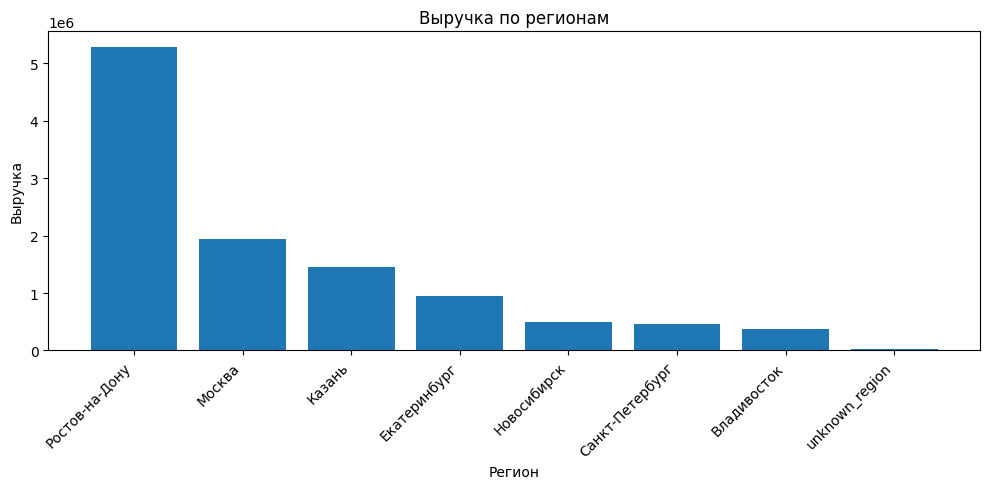

In [62]:
plt.figure(figsize=(10, 5))
plt.bar(region_summary["region_name"], region_summary["total_revenue"])
plt.title("Выручка по регионам")
plt.xlabel("Регион")
plt.ylabel("Выручка")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Вопрос для самопроверки

По графику ответьте:

1. В каком регионе выручка самая высокая?
2. Есть ли регионы с заметно меньшей выручкой?
3. Можно ли делать окончательный управленческий вывод только по этому графику?

Подсказка: окончательный вывод требует проверки качества данных и понимания контекста.

# Часть 13. Самостоятельная мини-практика

Используйте таблицу `sales_full`.

Нужно получить три результата:

1. Топ-3 региона по выручке.
2. Топ-3 категории по количеству заказов.
3. Средняя выручка заказа по каналам продаж.

Подсказка: используйте `groupby`, `agg`, `sort_values`, `head`.

## Задание 1. Топ-3 региона по выручке

In [63]:
top_regions = (
    sales_full
    .groupby("region_name", as_index=False)
    .agg(
        total_revenue=("revenue", "sum")
    )
    .sort_values("total_revenue", ascending=False)
    .head(3)
)

display(top_regions)

,region_name,total_revenue
6,Ростов-на-Дону,5291417.633
4,Москва,1939695.058
3,Казань,1457443.737


## Задание 2. Топ-3 категории по количеству заказов

In [64]:
top_categories_by_orders = (
    sales_full
    .groupby("category", as_index=False)
    .agg(
        orders_count=("order_id", "nunique")
    )
    .sort_values("orders_count", ascending=False)
    .head(3)
)

display(top_categories_by_orders)

,category,orders_count
0,accessories,46
1,electronics,38
2,furniture,27


## Задание 3. Средняя выручка заказа по каналам

In [65]:
channel_avg_order = (
    sales_full
    .groupby("channel", as_index=False)
    .agg(
        avg_order_revenue=("revenue", "mean"),
        orders_count=("order_id", "nunique")
    )
    .sort_values("avg_order_revenue", ascending=False)
)

display(channel_avg_order)

,channel,avg_order_revenue,orders_count
3,partner,147800.526097,31
2,online,84812.577044,34
0,marketplace,75480.423383,30
1,offline,73710.133559,17


# Отчёт о качестве данных

Сводный отчёт фиксирует состояние данных до и после очистки, количество
исключённых строк и число потенциальных выбросов.

In [66]:
invalid_dates_before = pd.to_datetime(
    sales["order_date"],
    errors="coerce",
).isna().sum()

quality_report = pd.DataFrame(
    [
        {
            "metric": "Количество строк",
            "before": len(sales),
            "after": len(sales_clean),
        },
        {
            "metric": "Всего пропущенных значений",
            "before": int(sales.isna().sum().sum()),
            "after": int(sales_clean.isna().sum().sum()),
        },
        {
            "metric": "Повторные order_id",
            "before": int(sales["order_id"].duplicated().sum()),
            "after": int(sales_clean["order_id"].duplicated().sum()),
        },
        {
            "metric": "Некорректные даты",
            "before": int(invalid_dates_before),
            "after": int(sales_clean["order_date"].isna().sum()),
        },
        {
            "metric": "Количество <= 0",
            "before": int((sales["quantity"] <= 0).sum()),
            "after": int((sales_clean["quantity"] <= 0).sum()),
        },
        {
            "metric": "Цена <= 0",
            "before": int((sales["unit_price"] <= 0).sum()),
            "after": int((sales_clean["unit_price"] <= 0).sum()),
        },
        {
            "metric": "Скидка вне диапазона",
            "before": int(
                (
                    (sales["discount"] < 0) |
                    (sales["discount"] > 1)
                ).sum()
            ),
            "after": int(
                (
                    (sales_clean["discount"] < 0) |
                    (sales_clean["discount"] > 1)
                ).sum()
            ),
        },
        {
            "metric": "Строк в карантине",
            "before": 0,
            "after": len(quarantine),
        },
        {
            "metric": "Потенциальные выбросы IQR",
            "before": None,
            "after": int(sales_clean["is_outlier_iqr"].sum()),
        },
        {
            "metric": "Потенциальные выбросы z-score",
            "before": None,
            "after": int(sales_clean["is_outlier_zscore"].sum()),
        },
    ]
)

display(quality_report)

,metric,before,after
0,Количество строк,121.0,112
1,Всего пропущенных значений,7.0,0
2,Повторные order_id,1.0,0
3,Некорректные даты,2.0,0
4,Количество <= 0,2.0,0
5,Цена <= 0,2.0,0
6,Скидка вне диапазона,2.0,0
7,Строк в карантине,0.0,9
8,Потенциальные выбросы IQR,NaN,15
9,Потенциальные выбросы z-score,NaN,1


# Часть 14. Сохраняем результаты

Теперь сохраним итоговые файлы в папку `outputs`.

In [67]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

sales_full.to_csv(
    output_dir / "clean_sales_report.csv",
    index=False,
)
quarantine.to_csv(
    output_dir / "sales_quarantine.csv",
    index=False,
)
quality_report.to_csv(
    output_dir / "quality_report.csv",
    index=False,
)
outlier_review.to_csv(
    output_dir / "outliers_review.csv",
    index=False,
)

region_summary.to_csv(
    output_dir / "region_summary.csv",
    index=False,
)
segment_summary.to_csv(
    output_dir / "segment_summary.csv",
    index=False,
)
category_channel_pivot.to_excel(
    output_dir / "category_channel_pivot.xlsx"
)

with pd.ExcelWriter(output_dir / "additional_analysis.xlsx") as writer:
    top_regions.to_excel(
        writer,
        sheet_name="top_regions",
        index=False,
    )
    top_categories_by_orders.to_excel(
        writer,
        sheet_name="top_categories",
        index=False,
    )
    channel_avg_order.to_excel(
        writer,
        sheet_name="channel_avg_order",
        index=False,
    )

print("Файлы сохранены:")
for file_path in sorted(output_dir.iterdir()):
    print(file_path)

Файлы сохранены:
outputs/additional_analysis.xlsx
outputs/category_channel_pivot.xlsx
outputs/clean_sales_report.csv
outputs/outliers_review.csv
outputs/quality_report.csv
outputs/region_summary.csv
outputs/sales_quarantine.csv
outputs/segment_summary.csv


# Часть 15. Аналитический вывод

Заполните вывод по шаблону.

Не пишите слишком общий вывод вроде:

> Данные были проанализированы.

Хороший вывод должен ссылаться на конкретные показатели.

## Мой аналитический вывод

1. Больше всего выручки получено в регионе: ...
2. Самая сильная категория по выручке: ...
3. Наиболее заметный канал продаж: ...
4. Перед использованием результата нужно учитывать, что часть данных была очищена или исключена по правилам качества.
5. Следующий шаг анализа может быть таким: ...

# Часть 16. Финальная самопроверка

| Проверка | Статус |
|---|---|
| Notebook запускается сверху вниз |  |
| Учебные данные созданы |  |
| Файлы в `data/raw` существуют |  |
| Данные загружены из CSV, XLSX и JSON |  |
| Проверены размеры таблиц |  |
| Проверены первые строки |  |
| Проверены типы данных |  |
| Найдены пропуски |  |
| Найдены дубликаты |  |
| Очищен `channel` |  |
| Преобразован `order_date` |  |
| Удалены дубликаты `order_id` |  |
| Обработаны пропуски |  |
| Исключены некорректные количества |  |
| Исключены некорректные цены |  |
| Проверены скидки |  |
| Рассчитан `revenue` |  |
| Создан `order_month` |  |
| Выполнено объединение с товарами |  |
| Выполнено объединение с регионами |  |
| Выполнено объединение с клиентами |  |
| Построены группировки |  |
| Построена сводная таблица |  |
| Построен график |  |
| Итоговые файлы сохранены |  |
| Написан аналитический вывод |  |

# Часть 17. Типовые ошибки и простые исправления

| Ошибка | Что означает | Что проверить |
|---|---|---|
| `FileNotFoundError` | Python не нашёл файл | путь, папку, имя файла |
| `ModuleNotFoundError` | не установлена библиотека | импорт и установку пакетов |
| `KeyError` | нет такого столбца | `df.columns.tolist()` |
| `NameError` | переменная не создана | выполнены ли предыдущие ячейки |
| `TypeError` | операция не подходит для типа данных | типы через `df.dtypes` |
| `ValueError` | значение не подходит для операции | конкретное значение и формат |
| CSV открылся одной колонкой | неверный разделитель | попробовать `sep=";"` |
| Даты стали пропусками | есть плохие даты | посмотреть строки с `isna()` |
| После `merge` появились пропуски | ключ не найден в справочнике | проверить ключи и пробелы |
| После `merge` стало больше строк | дубликаты в справочнике | проверить уникальность ключей |

- [ ] Числовые пропуски заполнены средним значением.
- [ ] Исключённые строки сохранены в карантин.
- [ ] Выбросы найдены методами IQR и z-score.
- [ ] Выбросы не удалены автоматически без проверки.
- [ ] Валидация через `assert` проходит без ошибок.
- [ ] В `merge()` указано отношение ключей через `validate`.
- [ ] Сохранены `sales_quarantine.csv`, `quality_report.csv` и `outliers_review.csv`.

# Часть 18. Мини-шпаргалка pandas

## Посмотреть первые строки

```python
df.head()
```

## Посмотреть размер

```python
df.shape
```

## Посмотреть столбцы

```python
df.columns.tolist()
```

## Посмотреть типы

```python
df.dtypes
```

## Посмотреть пропуски

```python
df.isna().sum()
```

## Посмотреть уникальные значения

```python
df["column"].unique()
```

## Отфильтровать строки

```python
df[df["column"] > 0]
```

## Сгруппировать данные

```python
df.groupby("group_column").agg(total=("value_column", "sum"))
```

## Объединить таблицы

```python
left_table.merge(right_table, on="key", how="left")
```

## Сохранить CSV

```python
df.to_csv("result.csv", index=False)
```

# Конец практической работы

Главная идея занятия:

> Аналитик должен не только посчитать показатель, но и проверить, можно ли доверять данным, на которых этот показатель построен.

Вы прошли полный цикл:

1. Создали учебные данные.
2. Проверили файлы.
3. Загрузили таблицы.
4. Нашли ошибки.
5. Очистили данные.
6. Преобразовали признаки.
7. Объединили справочники.
8. Рассчитали показатели.
9. Построили сводную таблицу и график.
10. Сохранили результат.
11. Сформулировали вывод.